<a href="https://colab.research.google.com/github/marilynsanchez511-pixel/marilynsan/blob/main/FinalRealProjectSCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/

[Errno 2] No such file or directory: 'drive/MyDrive/'
/content/drive/MyDrive/BIO2110PROJECT


In [ ]:
cd BIO2110PROJECT/

[Errno 2] No such file or directory: 'BIO2110PROJECT/'
/content/drive/MyDrive/BIO2110PROJECT


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA

In [ ]:
expr = pd.read_csv("GSE102881_expressionMatrix_cpm.txt.gz",sep="\t", compression="gzip")

In [ ]:
expr.columns #checking column names

Index(['Symbol', 'SCD_mobPB_Plerixafor_2', 'SCD_mobPB_Plerixafor_3',
       'SCD_mobPB_Plerixafor_1', 'HD_BM_1', 'HD_BM_2', 'SCD_BM_1', 'SCD_BM_2',
       'HD_mobPB_Plerixafor_1', 'HD_mobPB_Plerixafor_2',
       'HD_mobPB_Filgrastim_1', 'HD_mobPB_Filgrastim_2',
       'HD_mobPB_Filgrastim_3'],
      dtype='object')

In [ ]:
expr = expr.set_index("Symbol") #formats to have the each gene to a sample

In [ ]:
expr.index[:10] #checking for gene names

Index(['WASH7P', 'MIR6859-1', 'RP11-34P13.15', 'RP11-34P13.16',
       'RP11-34P13.13', 'FO538757.1', 'AP006222.2', 'RP4-669L17.10', 'U6',
       'MTND1P23'],
      dtype='object', name='Symbol')

In [ ]:
#manual dataframe so eash sample has condition is recorded, easier to group healthy and non.
metadata = pd.DataFrame({
    "sample_id": [
        "GSM2747679","GSM2747680","GSM2747681",
        "GSM2747682","GSM2747683",
        "GSM2747684","GSM2747685",
        "GSM2747686","GSM2747687",
        "GSM2747688","GSM2747689","GSM2747690"
    ],
    "title": [
        "SCD_mobPB_Plerixafor_2",
        "SCD_mobPB_Plerixafor_3",
        "SCD_mobPB_Plerixafor_1",
        "HD_BM_1",
        "HD_BM_2",
        "SCD_BM_1",
        "SCD_BM_2",
        "HD_mobPB_Plerixafor_1",
        "HD_mobPB_Plerixafor_2",
        "HD_mobPB_Filgrastim_1",
        "HD_mobPB_Filgrastim_2",
        "HD_mobPB_Filgrastim_3"
    ],
    "disease": [
        "SCD","SCD","SCD",
        "healthy","healthy",
        "SCD","SCD",
        "healthy","healthy",
        "healthy","healthy","healthy"
    ],
    "tissue": [
        "peripheral blood","peripheral blood","peripheral blood",
        "bone marrow","bone marrow",
        "bone marrow","bone marrow",
        "peripheral blood","peripheral blood",
        "peripheral blood","peripheral blood","peripheral blood"
    ],
    "drug": [
        "Plerixafor","Plerixafor","Plerixafor",
        "none","none",
        "none","none",
        "Plerixafor","Plerixafor",
        "Filgrastim","Filgrastim","Filgrastim"
    ],
    "replicate": [
        2,3,1,
        1,2,
        1,2,
        1,2,
        1,2,3
    ]
})

In [ ]:
expr_scd = expr[metadata.loc[metadata["disease"]=="SCD", "title"]]
expr_healthy = expr[metadata.loc[metadata["disease"]=="healthy", "title"]]

In [ ]:
stats = []
pvals = []
genes = []
#Getting the p values, U statistic to get sample expression
for gene in expr.index:
    scd_vals = expr_scd.loc[gene].values
    healthy_vals = expr_healthy.loc[gene].values

    stat, p = mannwhitneyu(
        scd_vals,
        healthy_vals,
        alternative="two-sided",
        method="asymptotic"
    )

    stats.append(stat)
    pvals.append(p)
    genes.append(gene)

In [ ]:
len(expr.index), len(stats), len(pvals) #test to make sure everything matches by looping for every gene

(21057, 21057, 21057)

In [ ]:
results = pd.DataFrame({ #new result dataframe
    "gene": genes,
    "log2FC": np.log2(expr_scd.loc[genes].mean(axis=1) + 1) -
              np.log2(expr_healthy.loc[genes].mean(axis=1) + 1),
    "mw_stat": stats,
    "p_value": pvals
})
results = results.sort_values("p_value") #Benjamini Hochberg FDR needs p values to be sorted from smallest to largest
m = len(results) #number of tested genes
results["adj_p"] = results["p_value"] * m / (np.arange(m) + 1) #BH FDR formula
results = results.sort_values("adj_p") #ordered by the most significant genes


In [ ]:
sig_combo = results[(results["p_value"] < 0.01) & (abs(results["log2FC"]) > 1)] #defines whats significant
sig_combo.head()#check

,gene,log2FC,mw_stat,p_value,adj_p
Symbol,,,,,
HLA-DMB,HLA-DMB,1.038091,34.0,0.009366,1.095679
LMNA,LMNA,-1.708374,1.0,0.009366,1.101800
AHNAK2,AHNAK2,1.446574,34.0,0.009366,1.107990
SCN3A,SCN3A,1.423078,34.0,0.009366,1.120581
MICAL2,MICAL2,-1.279690,1.0,0.009366,1.133461


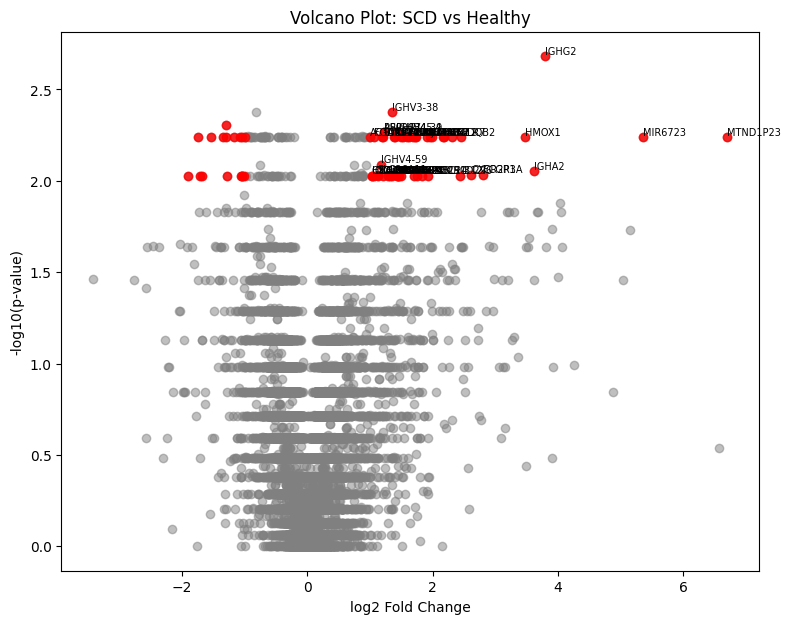

In [ ]:
#Volcano Plot
up_sig = sig_combo[sig_combo["log2FC"] > 0]

plt.figure(figsize=(9,7))
plt.scatter(results["log2FC"], -np.log10(results["p_value"]), color="gray", alpha=0.5)

plt.scatter(sig_combo["log2FC"],
            -np.log10(sig_combo["p_value"]),
            color="red", alpha=0.8)

#Lables the points with genes
for _, row in up_sig.iterrows():
    plt.text(row["log2FC"],
             -np.log10(row["p_value"]),
             row["gene"],
             fontsize=7,
             ha='left',
             va='bottom')


plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot: SCD vs Healthy")

plt.show()


In [ ]:
#Prints the upregulated genes
up_sig = sig_combo[sig_combo["log2FC"] > 0]
print(up_sig["gene"].tolist())



['HLA-DMB', 'AHNAK2', 'SCN3A', 'GBP1', 'LRRC25', 'CTC-248O19.1', 'TLR4', 'CD226', 'MS4A7', 'MTND1P23', 'VNN1', 'RP11-248C1.3', 'CD48', 'CX3CR1', 'RP11-404F10.2', 'NEXN', 'NCF1C', 'FGL2', 'TLR7', 'KIAA0513', 'LGALS3BP', 'CLEC4A', 'TNFSF8', 'OLFML2A', 'AC104634.3', 'XXbac-BPG248L24.12', 'IGHV4-59', 'CECR1', 'CXCR2P1', 'TAP1', 'SLC26A11', 'IGHA2', 'FCGR3A', 'LINC00865', 'JCHAIN', 'LILRA1', 'HLA-DQB2', 'CMPK2', 'FGD6', 'CD180', 'OAS2', 'STAP1', 'NCF2', 'HMOX1', 'MIR6723', 'GCSAM', 'AP000345.4', 'IGHV4-39', 'PSPHP1', 'IGHG2', 'IGHV3-38']


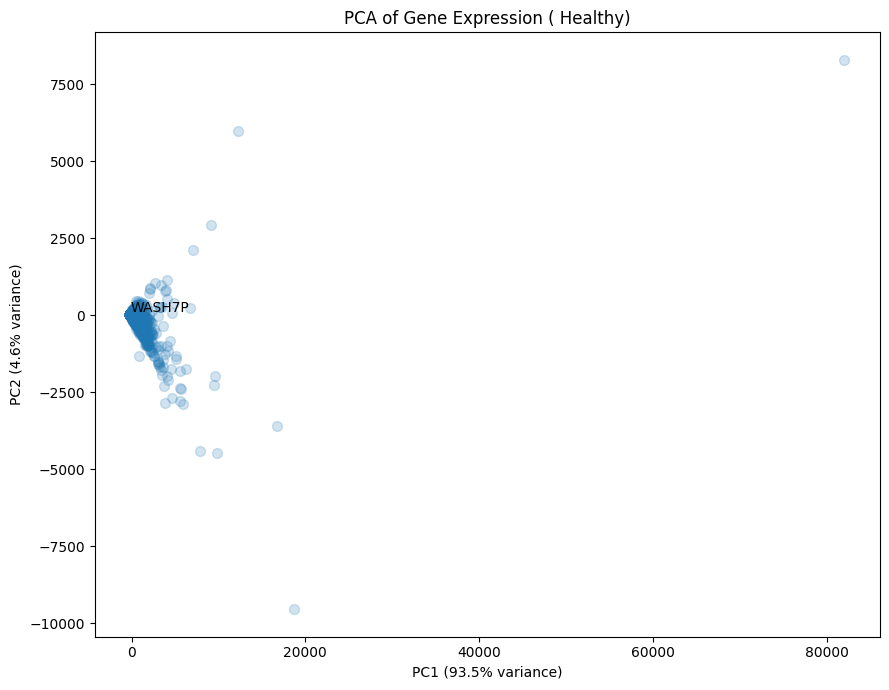

In [ ]:
X = expr_healthy.values
# Run PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

# Extract PC1 and PC2
pc1 = pcs[:, 0]
pc2 = pcs[:, 1]


plt.figure(figsize=(9,7))
plt.scatter(pc1,pc2, s=50, alpha=.2)

for i in range(1):
  plt.text(pc1[i], pc2[2], expr_healthy.index[i], fontsize=10, ha="left", va="bottom")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of Gene Expression ( Healthy)")

plt.tight_layout()
plt.show()

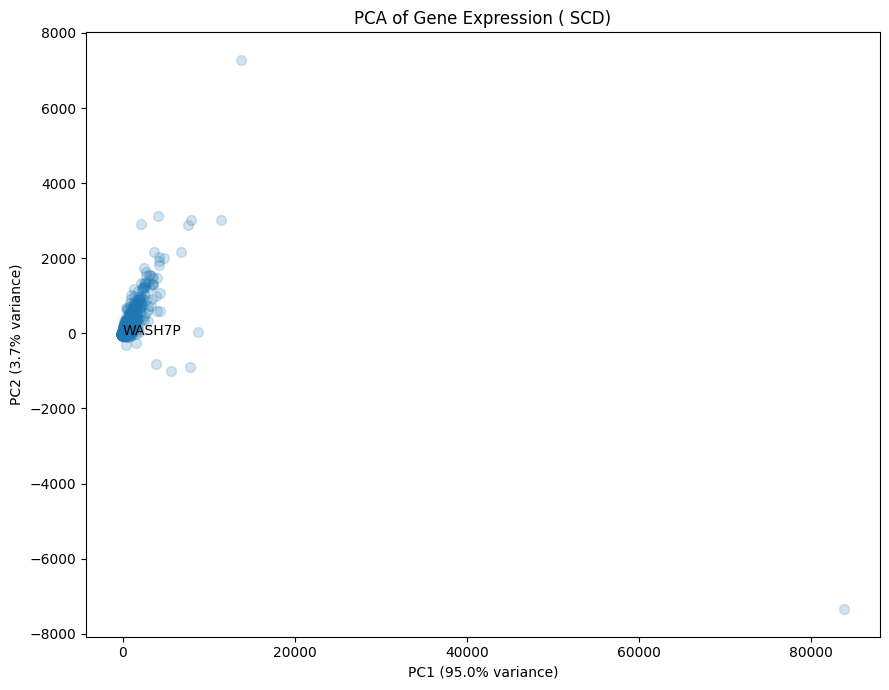

In [ ]:
X = expr_scd.values
# Run PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

# Extract PC1 and PC2
pc1 = pcs[:, 0]
pc2 = pcs[:, 1]


plt.figure(figsize=(9,7))

plt.scatter(pc1,pc2, s=50, alpha=.2 )

for i in range(1):
  plt.text(pc1[i], pc2[2], expr_scd.index[i], fontsize=10)


plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of Gene Expression ( SCD)")

plt.tight_layout()
plt.show()